# Семинар. Польза регуляризации.

Регуляризация — это важный и эффективный метод, применяемый в машинном обучении для решения ряда практических задач.

В этом ноутбуке мы увидим на простых примерах, как введение специальных ограничений на коэффициенты линейной модели помогает справляться с переобучением, неустойчивостью предсказаний и мультиколлинеарностью признаков.

In [38]:
import numpy as np
import pandas as pd
import scipy.stats as sps

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import ipywidgets as widgets
from typing import Tuple, Optional, Any, Dict, List, Union

import warnings

warnings.filterwarnings("ignore")

import seaborn as sns

sns.set_theme("notebook", font_scale=1.2, palette="Set2")

# Сохраним цветовую палитру установленной темы Matplotlib
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Переобучение и неустойчивость модели

Для начала рассмотрим простой пример, демонстрирующий явление переобучения.

### 1.1 Идеальные данные

Определим многочлен третьей степени:

$$
    f(x) = 3x^3 - 2x^2 + x + 2
$$

In [39]:
def f(x: np.ndarray[float]):
    """Целевая функция"""
    return 3 * (x**3) - 2 * (x**2) + x + 2

Создадим сетку из 300 точек для отрисовки графиков:

In [40]:
x_grid = np.linspace(-1, 1, 300).reshape(-1, 1)
y_grid_values = f(x_grid)

Изобразим график целевой функции на заданной сетке:

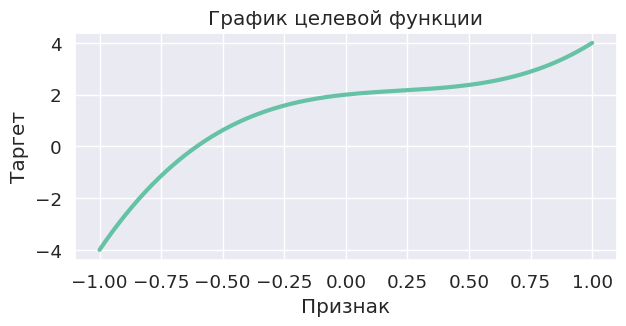

In [41]:
plt.figure(figsize=(6.5, 3.5), tight_layout=True)
plt.plot(x_grid, y_grid_values, linewidth=3)
plt.title("График целевой функции")
plt.xlabel("Признак")
plt.ylabel("Таргет");

Сгенерируем обучающую выборку из 10 случайных точек на отрезке $[-1,1]$:

In [42]:
sample_size = 10

# Фиксируем обучающую выборку
x_train = sps.uniform.rvs(
    loc=-1,  # начало отрезка
    scale=2,  # длина отрезка
    size=(sample_size, 1),  # размерность выходного массива
    random_state=RANDOM_STATE,
)
y_train = f(x_train)

Определим функцию для визуализации экспериментов:

In [43]:
def plot_poly(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_grid: np.ndarray,
    y_grid_values: np.ndarray,
    y_approx: np.ndarray,
    graph_title: str,
):
    """Функция для визуализации приближения многочленом.

    Args:
        x_train (np.ndarray): Узлы аппроксимации (обучающая выборка, регрессоры)
        y_train (np.ndarray): Отклики на обучающей выборке (таргет)
        x_grid (np.ndarray): Сетка для визуализации (тестовая выборка)
        y_grid_values (np.ndarray): Значения целевой функции на сетке
        y_approx (np.ndarray): Полученное приближение для y_grid_values
        graph_title (str): Заголовок для графика
    """

    plt.figure(figsize=(6.5, 3.5), tight_layout=True)

    plt.scatter(x_train, y_train, s=100, label="Обучающая выборка")
    plt.plot(x_grid, y_grid_values, label="Целевая функция", linewidth=5)
    plt.plot(x_grid, y_approx, label="Аппроксимация", linewidth=3)

    plt.title(graph_title)
    plt.xlabel("Признак")
    plt.ylabel("Таргет")
    plt.legend()
    plt.ylim((-4.5, 4.5))

>#### Пара технических моментов
>
>Для того, чтобы строить полиномиальные приближения моделями `sklearn`, необходимо преобразовать одномерный массив $x$ в матрицу, в столбцах которой будут степени $x$. Для этого можно использовать готовый трансформер из `sklearn` &mdash; [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).
>
> **Важные аргументы конструктора:**
>*   `degree` &mdash; максимальная степень
>*   `include_bias` &mdash; добавлять ли сдвиг (т. е. нулевую степень). По умолчанию, `True`.
>
>**Основные методы класса:**
>*   `fit(X)` &mdash; считает количество признаков в `X`
>*   `transform(X)` &mdash; присоединяет к массиву `X` массивы `X`$^2$, `X`$^3$ и т.д.
>
>   *Примечание*. В общем случае `X` может быть матрицей с $d \geq 1$ признаками.

In [44]:
# Создаём трансформер с заданной степенью многочлена
poly_features = PolynomialFeatures(degree=3).set_output(transform="pandas")

# Делаем преобразование массивов
X_train_poly = poly_features.fit_transform(x_train)
X_true_poly = poly_features.transform(x_grid)
X_train_poly.head(3)

,1,x0,x0^2,x0^3
0,1.0,-0.250920,0.062961,-0.015798
1,1.0,0.901429,0.812574,0.732477
2,1.0,0.463988,0.215285,0.099890


>Заметим, что у нас вырисовывается некий *пайплайн*, т.е. шаблонный алгоритм:
>1.  Сначала мы преобразуем признак
>2.  Затем обучаем модель
>
>Эти шаги неразделимы, поэтому удобно поместить их в один "контейнер" и работать с ним как с обычной моделью. Для этого в `sklearn` придумали класс [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):

In [45]:
from sklearn.pipeline import Pipeline

model = Pipeline(
    [
        # Сначала преобразование над x (одно или несколько)
        ("step_1", PolynomialFeatures(degree=3)),
        # В конце - модель, обладающая методами fit и predict
        ("step_2", LinearRegression(fit_intercept=False)),
    ]
)

>Теперь можно работать с `model` также, как с любой моделью `sklearn`, при этом преобразование над признаками будет происходить автоматически.

#### Возвращаемся к данным
Попробуем приблизить выборку кубическим полиномом:

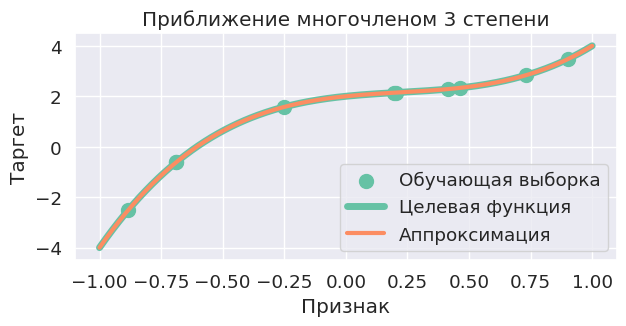

In [46]:
# Теперь fit автоматически добавляет полиномиальные фичи
# и обучает линейную регрессию
model.fit(x_train, y_train)

# Аналогично работает предсказание
y_approx = model.predict(x_grid)

title = f"Приближение многочленом {model.get_params()['step_1__degree']} степени"

# Визуализация
plot_poly(x_train, y_train, x_grid, y_grid_values, y_approx, title);

Получаем идеальное совпадение. А если взять, скажем, 7-ю степень?

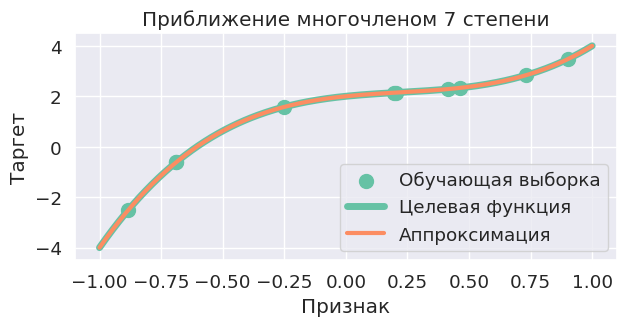

In [47]:
# Чтобы поменять степень, надо изменить параметр `degree` на шаге `step_1`
model["step_1"].set_params(degree=7)

# Обучаем модель и считаем приближение на тестовой сетке x_test
model.fit(x_train, y_train)
y_approx = model.predict(x_grid)

title = f"Приближение многочленом {model.get_params()['step_1__degree']} степени"

# Визуализация
plot_poly(x_train, y_train, x_grid, y_grid_values, y_approx, title);

Результат такой же. Неудивительно, ведь искомый многочлен сам по себе даёт минимально возможную ошибку $MSE = 0$:

$$
    f(x) = 2 + x - 2x^2 + 3x^3.
$$

Убедимся, что коэффициенты нашей модели в точности такие же:

In [48]:
print(model["step_2"].coef_[0])

[ 2.00000000e+00  1.00000000e+00 -2.00000000e+00  3.00000000e+00
  1.95482519e-13 -3.73031467e-13 -1.51711976e-13  2.94700896e-13]


Коэффициенты при $x^4,...,x^7$ можно считать нулевыми.

### 1.2 Суровая реальность

На практике мы редко имеем идеальные данные, которые полностью отражают искомую зависимость.

Попробуем добавить в нашу функцию случайный шум:

In [49]:
def f_real(x: np.ndarray[float], random_state: int = 0):
    """Целевая функция + шум."""

    np.random.seed(random_state)
    noise = np.random.standard_normal(x.size).reshape(x.shape)

    return 3 * (x**3) - 2 * (x**2) + x + 2 + noise

И определим случайные таргеты на обучающей выборке:

In [50]:
y_train = f_real(x_train, RANDOM_STATE)

Далеко не всегда заранее известна степень полинома. К тому же, данные, как правило, многомерны. В реальности угадать точный вид зависимости часто не представляется возможным.

Посмотрим, например, как будет выглядеть приближение многочленом той же **7-й степени**:




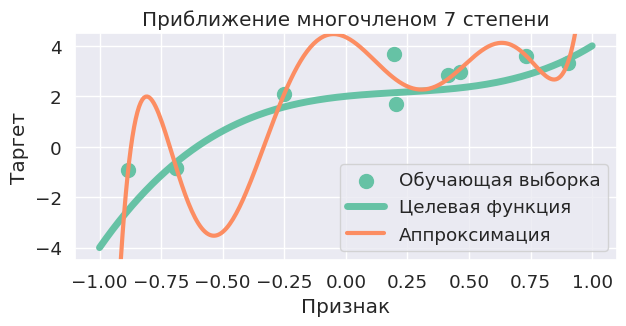

In [51]:
# Меняем степень
model["step_1"].set_params(degree=7)

# Обучаем модель и считаем приближение на тестовой сетке x_test
model.fit(x_train, y_train)
y_approx = model.predict(x_grid)

title = f"Приближение многочленом {model['step_1'].get_params()['degree']} степени"

# Визуализация
plot_poly(x_train, y_train, x_grid, y_grid_values, y_approx, title);

Именно так и проявляется переобучение: мы создали модель, которая слишком хорошо адаптировалась к тренировочным данным, фактически запомнив их. В результате, она **выучила не общую закономерность, а частные особенности тренировочной выборки**, включая шум. Такая модель не способна хорошо обобщаться на новые данные, которых раньше не видела.

### 1.3 Масштаб катастрофы

Если модель легко переобучается, то небольшие изменения в данных могут кардинально менять её поведение.

Чтобы явно увидеть это, проведём эксперимент: сгенерируем 100 аналогичных выборок и для каждой из них построим **свою** модель.

Генерируем выборки:

In [52]:
def generate_samples(samples_count: int, x_train: np.ndarray) -> List[np.ndarray]:
    """Генерирует samples_count откликов для выборки x_train.

    Args:
        samples_count (int): Количество сгенерированных выборок.
        x_train (np.ndarray): Исходные данные.

    Returns:
        List[np.ndarray]: Список массивов сгенерированных откликов.
    """

    return [f_real(x_train, random_state) for random_state in range(samples_count)]


# Вызов функции
y_train_all = generate_samples(100, x_train)

Напишем функцию, которая обучит линейную модель для каждой выборки из заданного набора и визуализирует полученные приближения:

In [53]:
def plot_many_poly(
    model: Pipeline,
    y_train_all: List[np.ndarray],
    x_train: np.ndarray,
    x_grid: np.ndarray,
    y_grid_values: np.ndarray,
    ax: Optional[Axes] = None,
    graph_title: str = "",
) -> Axes:
    """
    Обучает модель на разных реализациях отклика и отображает на графике полученные приближения.

    Args:
        y_train_all (List[np.ndarray]): Список массивов откликов для обучения.
        x_train (np.ndarray): Обучающая выборка.
        x_grid (np.ndarray): Сетка для визуализации.
        y_grid_values (np.ndarray): Значения целевой функции на тестовой сетке.
        ax (Axes): Ось для отрисовки. Если не передана, создаётся новая фигура.
        graph_title (str): Заголовок графика (по умолчанию — пустая строка).
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5), tight_layout=True)

    for y_train in y_train_all:
        model.fit(x_train, y_train)
        y_approx = model.predict(x_grid)
        ax.plot(x_grid, y_approx, linewidth=0.5, color=DEFAULT_COLORS[1])
        ax.scatter(x_train, y_train, s=200, alpha=0.5, color=DEFAULT_COLORS[0])

    ax.plot(x_grid, y_grid_values, label="Целевая функция", linewidth=5)
    ax.legend(loc="lower right")
    ax.set_ylim((-10, 10))
    ax.set_xlabel("Признак")
    ax.set_ylabel("Таргет")
    ax.set_title(graph_title)

    return ax

Данные у нас фиксированы, поэтому для краткости удобно передавать их в функцию единым словарём:

In [54]:
data_kwargs = {
    "x_train": x_train,  # тренировочная выборка
    "y_train_all": y_train_all,  # отклики на тренировочной выборке, много штук
    "x_grid": x_grid,  # тестова сетка
    "y_grid_values": y_grid_values,  # значения функции на сетке
}

И сам эксперимент:

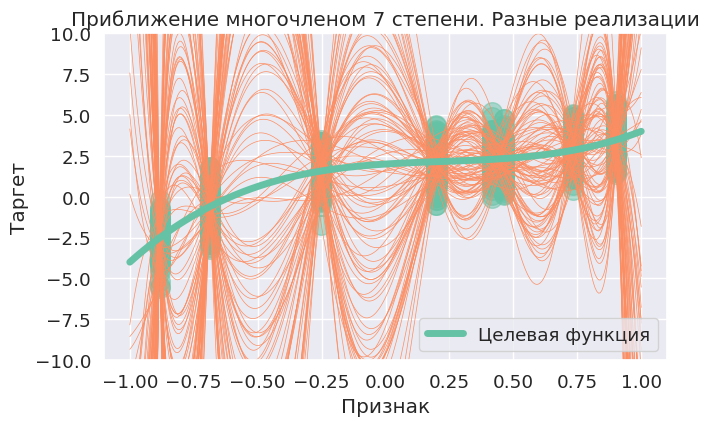

In [55]:
title = f"Приближение многочленом {model['step_1'].get_params()['degree']} степени. Разные реализации"

plot_many_poly(model=model, graph_title=title, **data_kwargs);

Важно отметить: **единственное, что менялось** при каждом повторении – это **значения таргета $y$**, из-за добавления к ним случайного (гауссова) шума. Это значит, что неустойчивость приближения напрямую связана с тем, как модель подстраивается под этот шум.

В результате, мы получили не только неточные приближения, но и крайне нестабильные. **Модель очень чувствительна к малым изменениям в тренировочных данных и ведет себя непредсказуемо.**

А что, если бы мы с самого начала выбрали правильную степень полинома? Возможно, тогда мы получили бы более качественную аппроксимацию? Давайте проверим это:

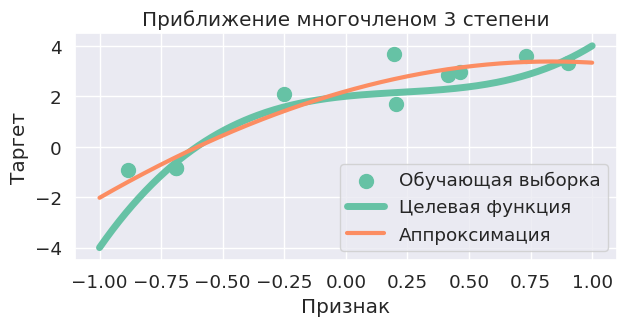

In [56]:
# Меняем степень
model["step_1"].set_params(degree=3)

# Обучаем модель и считаем приближение на тестовой сетке x_test
model.fit(x_train, y_train)
y_approx = model.predict(x_grid)

title = f"Приближение многочленом {model['step_1'].get_params()['degree']} степени"

# Визуализация
plot_poly(x_train, y_train, x_grid, y_grid_values, y_approx, title);

Хороший ли это результат? &mdash; Как повезёт. Всё также зависит от реализации $y$. Проведём аналогичный эксперимент:

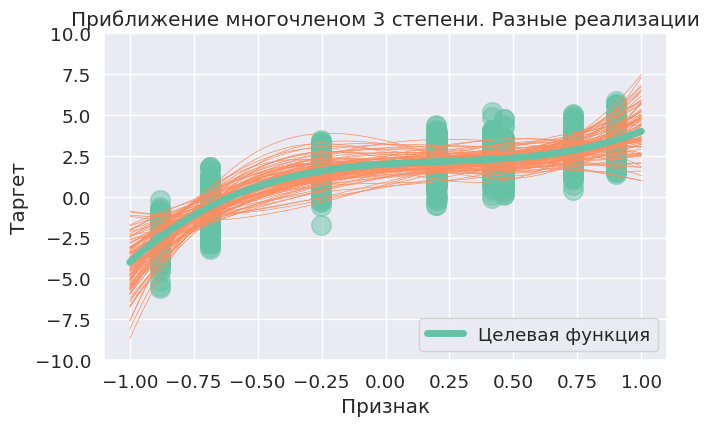

In [57]:
title = f"Приближение многочленом {model['step_1'].get_params()['degree']} степени. Разные реализации"

plot_many_poly(model=model, graph_title=title, **data_kwargs);

Выглядит значительно лучше, чем в случае 7-й степени. Тем не менее, даже здесь есть ряд заметных недостатков:

*   На правом краю интервала некоторые кривые начинают убывать, в то время как исходная функция имеет тенденцию к возрастанию.

*   Можно наблюдать значительную разницу в форме кривых: некоторые имеют неестественно большую выпуклость, а другие, напротив, почти линейны.



### **Отвлечёмся на лекцию**

... для того чтобы увидеть, с чем это связано и как с этим можно бороться.

### 1.4 Регуляризация повышает устойчивость

Ключевым моментом в двух последних примерах была излишняя отзывчивость моделей на шум. Регуляризация помогает игнорировать случайные колебания в данных, вводя дополнительное ограничение: теперь модель "штрафуется" за излишне большие коэффициенты. Меньше коэффициенты &mdash; меньше отклик на шум.

> &#x2755;*Замечание*&#x2755; Свободный коэффициент не штрафуется.
>
>В задаче линейной регрессии наиболее часто используют модели
 [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) и [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html).
>
> * **Ridge** &mdash; это модель линейной регрессии с $L_2$-регуляризацией, которая минимизирует функционал
>$$    \lVert Y - X \theta\rVert^2_2 + \alpha  \lVert\theta\rVert^2_2 → \min_\theta$$
>* **Lasso** &mdash; модель линейной регрессии с $L_1$-регуляризацией. Минимизирует функционал
>$$    \lVert Y - X \theta\rVert^2_2 + \alpha  \lVert\theta\rVert_1 → \min_\theta$$
>* **ElasticNet** &mdash; компромисс между двумя предыдущими. Минимизирует функционал
>$$    \lVert Y - X\theta\rVert^2_2 + \alpha_1  \lVert\theta\rVert_1 + \alpha_2  \lVert\theta\rVert^2_2 → \min_\theta$$
>Здесь $Y \in \mathbb{R}^{n}$ &mdash; истинные значения целевой переменной, $X \in \mathbb{R}^{n\times d}$ &mdash; матрица "объект-признак", ${\theta} \in \mathbb{R}^{d}$ &mdash; коэффициенты модели. Параметр регуляризации $\alpha \geq 0$ управляет силой штрафа. Является **гиперпараметром**, т.е. задаётся пользователем.

Также важно помнить, что перед тем как применять регуляризацию, данные нужно стандартизировать.

&#x2753; **Зачем?** &#x2753;

<details>
  <summary> Кликни для показа ответа </summary>
  
> Поскольку гиперпараметр $\alpha$ умножается на норму коэффициентов модели, их необходимо *обезразмерить*. Действительно, если признак $x_1$ имеет размерность длины, $x_2$ &mdash; массы, а таргет безразмерный, то\
>$$y = \theta_1 [\text{м}^{-1}] \cdot x_1 [\text{м}] + \theta_2 [\text{кг}^{-1}] \cdot x_2 [\text{кг}] + ...$$
>Тогда при подсчёте нормы $\lVert\theta\rVert$ мы сложим обратные килограммы с обратными километрами &mdash; сомнительная затея..

</details><br/>

>Есть много способов стандартизации, из которых наиболее распространены два следующих.
>1. <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html"><it>StandardScaler</it></a>. Пусть $x_{ij}$ &mdash; значение признака $j$ для объекта $i$. Обозначим $m_j$ &mdash; выборочное среднее значение признака $j$ (функция `np.mean`), а $s^2_j$ &mdash; выборочную дисперсию признака $j$ (функция `np.var`). Тогда стандартизацией является преобразование
>$$    \widetilde{x}_{ij} = \frac{x_{ij} - m_j}{s_j}.$$
>2. <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html"><it>MinMaxScaler</it></a>. Пусть $x_{ij}$ &mdash; значение признака $j$ для объекта $i$. Обозначим $m_j$ и $M_j$ &mdash; минимальное и максимальное значения признака $j$ соответственно. Тогда стандартизацией является преобразование
>$$
    \widetilde{x}_{ij} = \frac{x_{ij} - m_j}{M_j - m_j}.
$$

Повторим эксперимент для модели с регуляризацией. Сравним с работой МНК. Для этого понадобится создать ещё один *пайплайн:*

In [58]:
model_reg = Pipeline(
    [
        # Учёт сдвига перенесём в саму модель, иначе после
        # стандартизации у нас получится просто нулевой столбец
        ("step_1", PolynomialFeatures(degree=3, include_bias=False)),
        # Добавили стандартизацию
        ("step_2", StandardScaler()),
        # Заменили LinearRegression на Ridge
        ("step_3", Ridge(fit_intercept=True, alpha=1)),
    ]
)

> 💡 Данные будут переходить от одного шага к другому, словно по конвейеру.

Ещё одна вспомогательная функция:

In [59]:
def combine_experiments(
    regularized_model: Pipeline,
    unregularized_model: Pipeline,
    figure_title: str = "",
    **kwargs,
):
    """Обучает две модели на разных реализациях отклика и отображает на графиках полученные приближения.

    Args:
        regularized_model (Pipeline): модель линейной регрессии с L2-регуляризацией
        unregularized_model (Pipeline): модель линейной регрессии без регуляризации
        figure_title (str, optional): подпись к рисунку. По умолчанию, пустая строка
        **fixed_kwargs: параметры, передаваемые в функцию plot_many_poly
    """

    models = [regularized_model, unregularized_model]
    titles = ["С регуляризацией", "Без регуляризации"]

    fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True, sharey=True)
    fig.suptitle(figure_title)

    for model, title, ax in zip(models, titles, axs):
        plot_many_poly(model, **{**kwargs, "ax": ax, "graph_title": title})

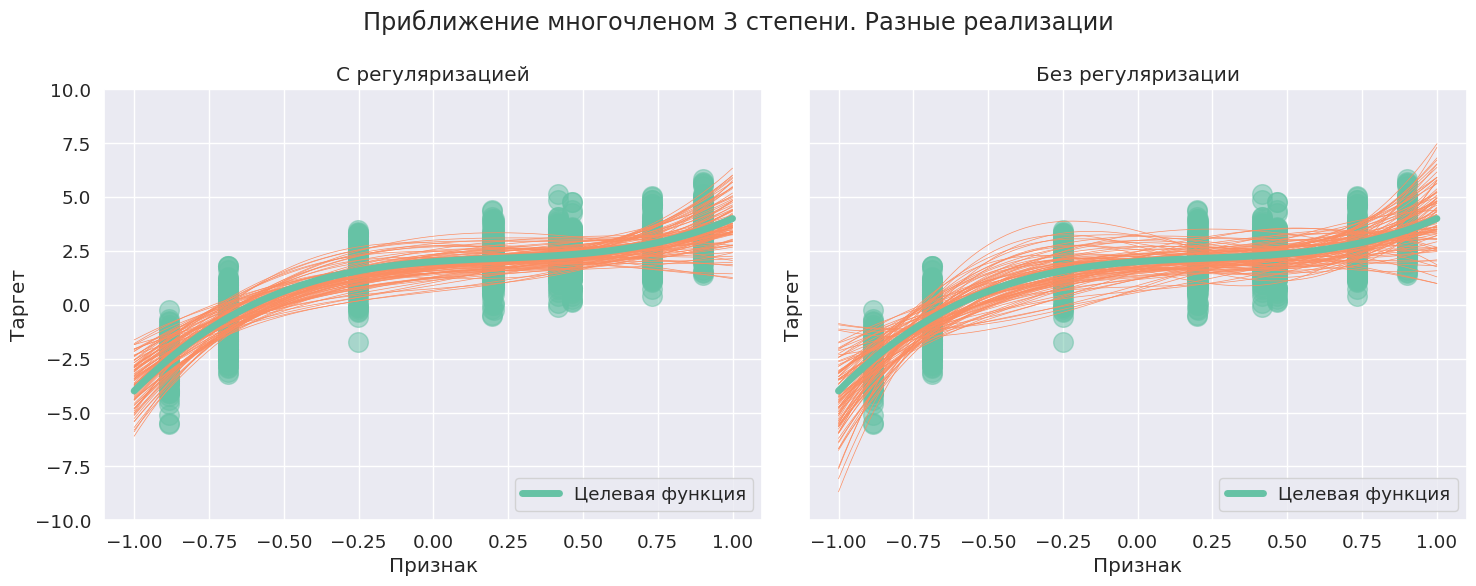

In [60]:
title = f"Приближение многочленом {model['step_1'].get_params()['degree']} степени. Разные реализации"

combine_experiments(model_reg, model, title, **data_kwargs)

Невооружённым глазом видно частичное устранение недостатков: кривые аппроксимации идут практически единым потоком, близко друг к другу, что свидетельствует о повышении устойчивости модели.

### 1.4 Что там с переобучением?

Вернёмся к степени 7. Применение регуляризации в этом случае сильно спасает ситуацию:

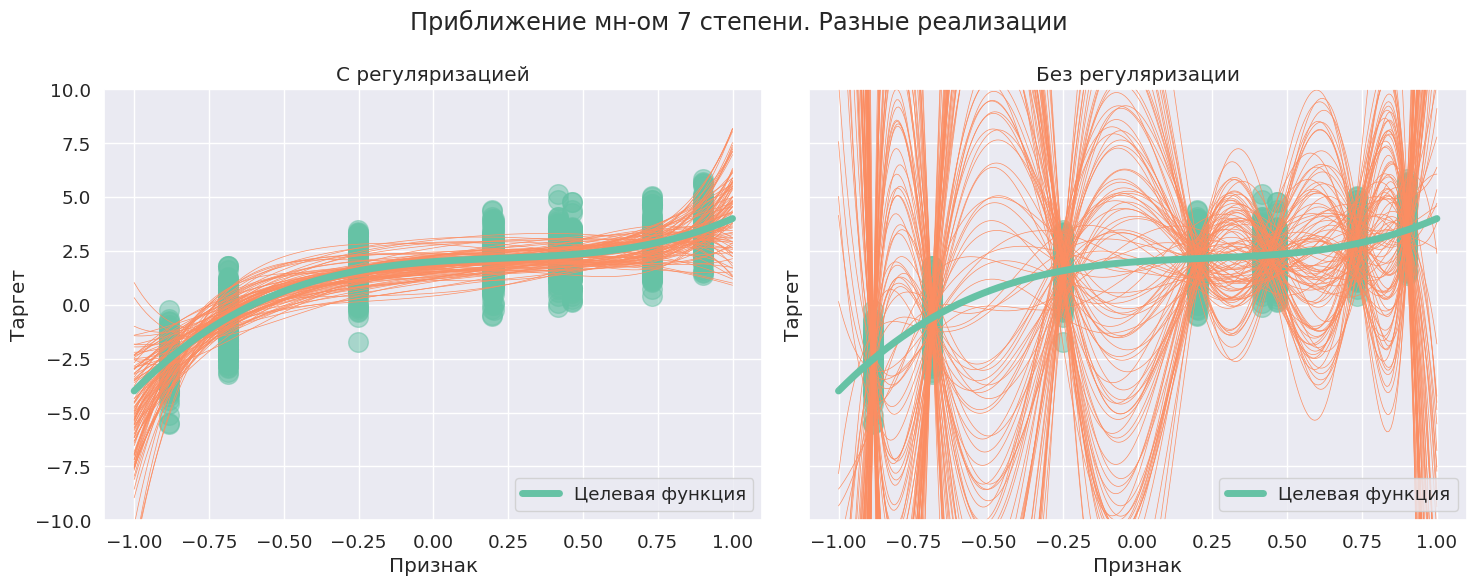

In [61]:
# Меняем степень
model["step_1"].set_params(degree=7)
model_reg["step_1"].set_params(degree=7)

title = f"Приближение мн-ом {model['step_1'].get_params()['degree']} степени. Разные реализации"

combine_experiments(model_reg, model, title, **data_kwargs)

Не так хорошо, как с 3-й степенью, однако результат всё равно впечатляет: исчезли ненужные осцилляции, практически все кривые задают единый тренд.

**Таким образом,** регуляризация:

*   повышает устойчивость модели: теперь при разных реализациях выборки модели ведут себя намного более согласованно;

*   избавляет от необходимости тщательного подбора вида искомой функции. Приближение многочленом как 3-й, так и 7-степени, даёт приемлемые результаты, за исключением, может быть, приграничных областей.





### 1.5 Настройка параметра штрафа ⚙️



Теперь посмотрим, как параметр регуляризации влияет на коэффициенты модели и предсказание. Для начала, напишем функцию, которая обучит модель с заданным `alpha`, нарисует график аппроксимации и отобразит коэффициенты.

In [62]:
def poly_regular_visualize(
    degree: int,
    model_type: str,
    alpha: float,
    max_iter: int,
    fit_intercept: bool,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_grid: np.ndarray,
    y_grid_values: np.ndarray,
):
    """Визуализирует предсказание и коэффициенты модели с заданным параметром регуляризации.

    Args:
        degree (int): Степень многочлена, которым делается приближение.
        model_type (str): Тип модели ('Ridge', 'Lasso' или 'Elastic').
        alpha (float): Коэффициент регуляризации.
        max_iter (int): Максимальное число итераций при обучении итеративным алгоритмом.
        fit_intercept (bool): Добавлять ли свободный коэффициент в модель.
        x_train (np.ndarray): Узлы аппроксимации (обучающая выборка, регрессоры).
        y_train (np.ndarray): Отклики на обучающей выборке.
        x_grid (np.ndarray): Сетка для визуализации (тестовая выборка).
        y_grid_values (np.ndarray): Значения целевой функции на тестовой выборке.
    """

    # Инициализируем нужную модель
    if model_type == "Ridge":
        LinearModelClass = Ridge
    elif model_type == "Lasso":
        LinearModelClass = Lasso
    elif model_type == "Elastic":
        LinearModelClass = ElasticNet

    model = LinearModelClass(
        alpha=alpha, max_iter=max_iter, fit_intercept=fit_intercept
    )
    # Для модели ElasticNet аргумент alpha одновременно регулирует введённые ранее alpha_1 и alpha_2
    # Чтобы менять соотношение между ними, есть ещё аргумент l1_ratio. Но пока он нам не нужен

    # Добавим к модели преобразования признаков и сразу обучим
    pipeline_model = Pipeline(
        [
            ("step_1", PolynomialFeatures(degree=degree, include_bias=False)),
            ("step_2", StandardScaler()),
            ("step_3", model),
        ]
    ).fit(x_train, y_train)

    # Получаем предсказания
    y_approx = pipeline_model.predict(x_grid)

    # Визуализация
    figure = plt.figure(figsize=(7, 6), tight_layout=True)

    # График предсказания
    plt.subplot(2, 1, 1)
    plt.scatter(x_train, y_train, s=100, label="Обучающая выборка")
    plt.plot(x_grid, y_grid_values, label="Целевая функция", linewidth=5)
    plt.plot(x_grid, y_approx, label="Аппроксимация", linewidth=3)
    plt.ylabel("Таргет")
    plt.xlabel("Признак")
    plt.legend(loc="lower right")

    # График коэффициентов
    plt.subplot(2, 1, 2)
    plt.bar(
        ["$x^0$"] + [f"$x^{{{p[0]}}}$" for p in pipeline_model["step_1"].powers_],
        np.ravel(model.intercept_).tolist() + np.ravel(model.coef_).tolist(),
    )
    plt.ylabel("Коэффициент")
    plt.xlabel("Номер коэффициента")

Переопределим отклики на обучающей выборке и создадим виджет для варьирования параметров модели:

In [63]:
y_train = f_real(x_train)

# Создаём виджеты
degree_wg = widgets.IntSlider(min=1, max=10, value=7, description="degree")
max_iter_wg = widgets.IntText(value=10, description="max_iter")
model_wg = widgets.Dropdown(
    options=["Ridge", "Lasso", "Elastic"], value="Ridge", description="model"
)
alpha_wg = widgets.FloatSlider(
    min=0.0001, max=5, step=0.01, value=0, description="alpha"
)
fit_intercept_wg = widgets.Checkbox(value=False, description="fit_intercept")

# Оформим их красиво
row1 = widgets.HBox([degree_wg, model_wg])
row2 = widgets.HBox([alpha_wg, max_iter_wg])
ui = widgets.VBox([row1, row2, fit_intercept_wg])

# Связываем виджеты с функцией
out = widgets.interactive_output(
    poly_regular_visualize,
    {
        "degree": degree_wg,
        "max_iter": max_iter_wg,
        "fit_intercept": fit_intercept_wg,
        "model_type": model_wg,
        "alpha": alpha_wg,
        "x_train": widgets.fixed(x_train),
        "y_train": widgets.fixed(y_train),
        "x_grid": widgets.fixed(x_grid),
        "y_grid_values": widgets.fixed(y_grid_values),
    },
)

# Отображаем
display(ui, out)

Output()

**Выводы**

*   При росте штрафа коэффициенты в пределе стремятся к нулю
*   Lasso-регрессия зануляет часть коэффициентов
*   Чем выше степень полинома, тем сильнее нужен штраф
*   Параметр `max_iter` не влияет на Ridge-регрессию, т. к. по умолчанию она использует точное решение, а не градиентный спуск

Предлагаем поиграться с параметрами самостоятельно.

### 1.6 Перебираем все "альфы"

А теперь посмотрим на общую картину: создадим сетку "альф", для каждого значения обучим модель и запомним коэффициенты. Ниже реализована соответствующая функция для произвольной линейной модели.

In [64]:
def train_alpha_grid(
    model: Pipeline, x_train: np.ndarray, y_train: np.ndarray, alpha_grid: np.ndarray
) -> np.ndarray:
    """Обучает модель для разных значений параметра регуляризации
    и сохраняет коэффициенты.

    Args:
        model (Pipeline): Пайплайн со степенями полинома, стандартизацией и моделью регуляризации.
        x_train (np.ndarray): Обучающая выборка.
        y_train (np.ndarray): Отклик на обучающей выборке.
        alpha_grid (np.ndarray): Массив значений параметра регуляризации (alpha).

    Returns:
        np.ndarray: Массив коэффициентов моделей с разной силой штрафа.
    """

    coefs = []

    for alpha in alpha_grid:
        # Устанавливаем новое значение alpha
        model["step_3"].set_params(alpha=alpha)
        # Обучаем модель
        model.fit(x_train, y_train)

        # Сохраняем коэффициенты (intercept_ + coef_)
        coefs.append(
            model["step_3"].intercept_.flatten().tolist()
            + model["step_3"].coef_.flatten().tolist()
        )

    return np.array(coefs)

Отдельно для каждой модели нарисуем треки всех коэффициентов в зависимости от альфа:

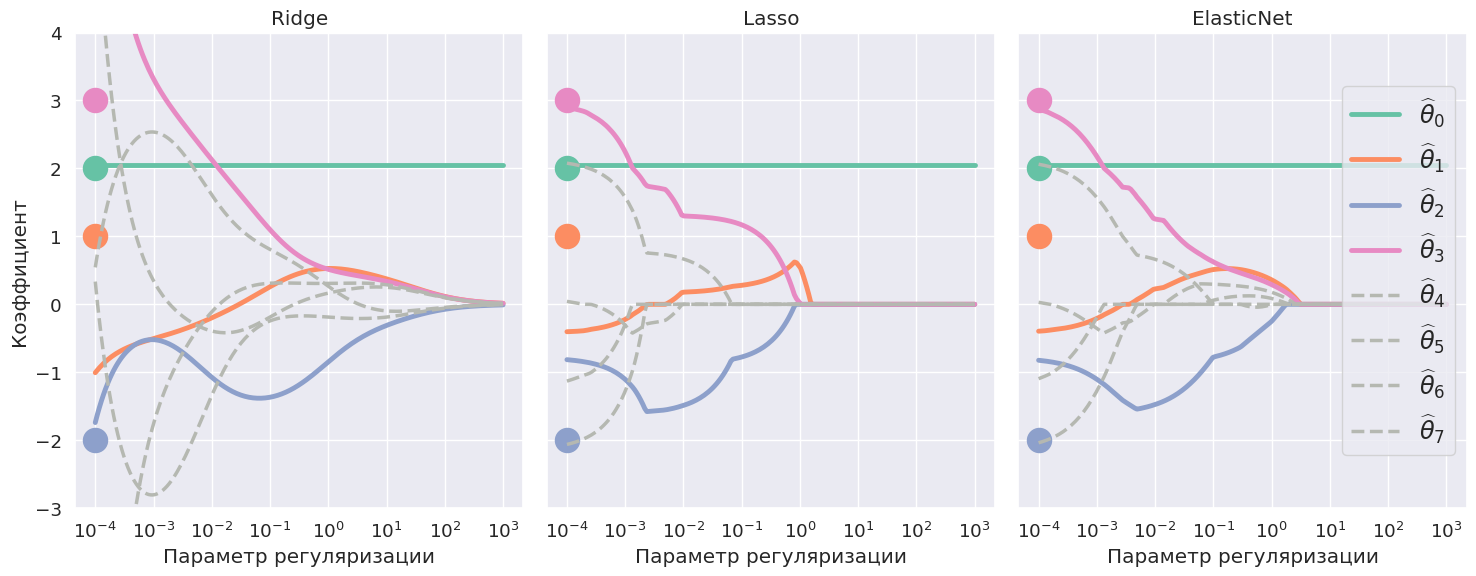

In [65]:
# Сетка значений alpha
alpha_grid = np.logspace(-4, 3, 200)

# Вновь рассматриваем три модели
models_dict = {
    "Ridge": Ridge(fit_intercept=True),
    "Lasso": Lasso(fit_intercept=True),
    "ElasticNet": ElasticNet(fit_intercept=True),
}

fig, ax_list = plt.subplots(1, 3, figsize=(15, 6), tight_layout=True, sharey=True)

# Сопоставим цвета для коэффициентов:
# первые 4 "правильных" — стандартно
# остальные — серым
colors = DEFAULT_COLORS[:4] + [(181 / 255, 184 / 255, 177 / 255)] * 4

# Перебираем модели и строим графики коэффициентов
for ax, (model_name, model) in zip(ax_list, models_dict.items()):

    model = Pipeline(
        [
            ("step_1", PolynomialFeatures(degree=7, include_bias=False)),
            ("step_2", StandardScaler()),
            ("step_3", model),
        ]
    )
    # Обучаем модель на различных значениях alpha и получаем коэффициенты
    coefs = train_alpha_grid(model, x_train, y_train, alpha_grid)

    # Истинные коэффициенты для сравнения
    true_coefs = [2, 1, -2, 3]

    # Визуализация изменения коэффициентов при разной alpha
    for i, coef_track in enumerate(coefs.T):
        if i < 4:
            ax.scatter(alpha_grid[0], true_coefs[i], marker="o", c=colors[i], s=300)
            lw, ls = 3.5, "-"
        else:
            lw, ls = 2.5, "--"
        ax.plot(
            alpha_grid,
            coef_track,
            label=f"$\\widehat{{\\theta}}_{i}$",
            color=colors[i],
            lw=lw,
            ls=ls,
        )

    # Настройка осей и заголовков
    ax.set_title(model_name)
    ax.set_xlabel("Параметр регуляризации")
    ax.set_xscale("log")
    ax.set_ylim((-3, 4))

# Общие настройки
ax_list[0].set_ylabel("Коэффициент")
ax_list[-1].legend(loc="right", fontsize="large");

$$
    f(x) = 3x^3 - 2x^2 + x + 2
$$

Кружочками 🟣🟢🟠🔵 отмечены истинные значения коэффициентов. Как мы видим, регуляризация не позволяет "исправить" их все одновременно. Некоторые и вовсе не достигают своих истинных значений.

Также отметим, что

*   Для Lasso-регрессии характерны резкие скачки в местах, где зануляется хотя бы один из коэффициентов

*   Elastic-регрессия являет собой нечто среднее: есть зануляющиеся коэффициенты, но спад более плавный, чем у Lasso


## 2. Проблема мультиколлинеарности

Переобучение и нестабильность модели часто являются следствием явления под названием *мультиколлинеарность*.

Это ситуация, когда между признаками существует линейная или почти линейная зависимость. Другими словами, признаки могут быть сильно скоррелированы, что приводит к нестабильным и часто завышенным коэффициентам модели.

В разобранном выше примере с аппроксимацией полиномом 7-й степени мы и наблюдали следствие таких корреляций. Скажем, связь между признаками $x^5$ и $x^7$ не так уж далека от линейной на отрезке $[-1, \, 1]$. И при увеличении степени эта разница лишь уменьшается. Как следствие, мы имели большой разброс в коэффициентах многочлена, выражавшийся в грандиозных отличиях аппроксимирующих кривых.

Мультиколлинеарность тесно связана с понятием **числа обусловленности** (condition index). Оно определяет  устойчивость многих численных методов, и линейной регрессии в том числе. Для квадратной матрицы $X^TX$ его можно определить как отношение её наибольшего и наименьшего собственных чисел:
$$
    \text{CI}(X^TX) = \frac{\lambda_1}{\lambda_n}
$$
Для прямоугольной матрицы $X$ верно простое соотношение:
$$
    \text{CI}(X) = \sqrt{\text{CI}(X^TX)}
$$
Чем меньше число обусловленности, тем более устойчиво решение задачи, т.е. обученная модель, в нашем случае.
> ℹ️ См. также про [сингулярное разложение.](http://www.machinelearning.ru/wiki/index.php?title=Сингулярное_разложение)

### 2.1 Разброс ответов модели

Отойдём от примера с многочленом и рассмотрим простую линейную комбинацию признаков:

$$
    y(x) = 1 + 2x_0 + 5x_1 + 3.5x_2 + x_3 - x_4 + ɛ, \hspace{1cm} \varepsilon \sim \mathcal{N}(0, 1)
$$

Если некоторые из них оказываются линейно зависимыми, то приближенная вещественнная функция &mdash; решение задачи регрессии &mdash; становится неоднозначной. Действительно, если $x_3 \equiv x_4$, то существует бесконечное множество наборов коэффициентов, например, $(\widehat{\theta}_0, \, \widehat{\theta}_1, \, \widehat{\theta}_2, \, \widehat{\theta}_3, \, \widehat{\theta}_4) = (a, \, b, \, c, \, 1, \, 1)$, или $(a, \, b, \, c, \, 100, \, 100)$, или $(a, \, b, \, c, \, -\pi, \, -\pi)$, и так далее, которые дают одинаковые предсказания.

> *Пример: аналитику для решения некоторой задачи выдали данные о финансовых делах компании. Среди признаков есть общая выручка, затраты, различные налоги, штрафы, пошлины и чистая прибыль* &mdash; *все они линейно связаны друг с другом.*

Очень часто линейная зависимость не является строгой, и тогда решение единственно. Тем не менее, даже небольшие изменения в данных могут привести к значительным колебаниям в значениях коэффициентов модели и, как следствие, к нестабильным прогнозам.

 🔎 *Исследуем конкретный пример*\
Пусть признаки $x_1$, $x_2$ и $x_3$ &mdash; приближённо линейно-зависимы:
$$
    x_3 = x_2 - 2.5x_1 + 2.5x_4 + \delta, \hspace{1cm} \delta \sim \mathcal{N}(0, σ_{noise}^2)
$$
Здесь $\delta$ — случайный шум, определяющий "силу" линейной зависимости между признаками.
Реализуем непосредственно линейную функцию, а также функцию, которая будет добавлять мультиколлинеарность в наши данные.

>&#x2755;*Замечание*&#x2755; Ранее мы добавляли шум только в целевую функцию, а теперь ещё и в признаки.

In [66]:
def target_function(x: np.ndarray, with_noise: bool = True) -> np.ndarray:
    """Целевая функция + шум"""

    noise = np.random.normal(0, 1, x.shape[0]) * with_noise
    return 1 + 2 * x[:, 0] + 5 * x[:, 1] + 3.5 * x[:, 2] + x[:, 3] - x[:, 4] + noise


def add_multicollinearity(x: np.ndarray, noise_std: float = 0.0001) -> np.ndarray:
    """Вносит погрешность в признак x4 для создания мультиколлинеарности"""

    x[:, 3] = (
        x[:, 2]
        - 2.5 * x[:, 1]
        + 2.5 * x[:, 4]
        + np.random.normal(0, noise_std, x.shape[0])
    )
    return x

Саму функцию визуализировать не будем, поскольку размерность экрана на 3 меньше числа переменных.

Линейная модель, аппроксимирующая данные:
$$
    \widehat{y} = X\widehat{\theta}
$$

Напишем функцию, которая будет обучать заданную модель много раз на таких синтетических данных и возвращать предсказания на одной заданной точке. При этом мы фиксируем признаки изначально, а $x_3$ и $y$ будут варьироваться из-за случайного шума.

> &#x2755;*Замечание*&#x2755; Попутно будем считать число обусловленности. В случае Ridge-регрессии с $\alpha \geq 0$ нас будет интересовать обусловленность матрицы $X^TX + \alpha I_5$

In [67]:
def single_prediction_variability(
    X_train: np.ndarray,
    X_test_point: np.ndarray,
    alpha: float = 0.0,
    n_repeats: int = 1000,
    feature_noise_std: float = 0.01,
) -> Tuple[np.ndarray, float]:
    """Обучает n_repeats раз Ridge-регрессию со штрафом alpha и возвращает
    предсказания на X_test_point вместе со средним числом обусловленности.

    Args:
        X_train (np.ndarray): Обучающая выборка (размерность [n_samples, n_features]).
        X_test_point (np.ndarray): Тестовая точка (размерность [1, n_features]).
        alpha (float): Коэффициент регуляризации.
        n_repeats (int): Число повторений.
        feature_noise_std (float): Стандартное отклонение шума в признаках (влияет на обусловленность).

    Returns:
        Tuple[np.ndarray, float]:
            - np.ndarray: Массив предсказаний на объекте X_test_point (размер n_repeats).
            - float: Среднее число обусловленности.
    """

    # Сюда будем записывать числа обусловленности
    cond_idx = np.empty(n_repeats, dtype=float)

    # Сюда будем записывать предсказания в точке X_test_point
    predictions = np.empty(n_repeats, dtype=float)

    # Создаём модель
    model = Pipeline(
        [
            ("step_1", StandardScaler()),
            ("step_2", Ridge(alpha=alpha, fit_intercept=True)),
        ]
    )
    for i in range(n_repeats):
        # Добавляем мультиколлинеарность и пересчитываем отклик
        X_train_bad = add_multicollinearity(X_train, noise_std=feature_noise_std)
        y_train = target_function(X_train)

        # Обучаем модель и делаем предсказание
        model.fit(X_train_bad, y_train)
        predictions[i] = model.predict(X_test_point)

        # Считаем число обусловленности
        X = X_train_bad.T @ X_train_bad + alpha * np.diag(np.ones(X_train.shape[1]))
        cond_idx[i] = np.sqrt(np.linalg.cond(X))  # Сохраняем в массив

    return predictions, cond_idx.mean()

Также напишем функцию, которая по заданным предсказаниям будет строить ядерную оценку плотности:

In [68]:
def visualize_as_kde(
    models_predictions: dict[str, np.ndarray],
    y_true_point: float,
    graph_title: str = "",
):
    """Строит ядерную оценку плотности (KDE) предсказаний моделей из словаря models_predictions.

    Args:
        models_predictions (dict[str, np.ndarray]):
            Словарь, где ключи — названия моделей, а значения — массивы предсказаний (размерности n_samples).
        y_true_point (float): Истинное значение отклика в тестовой точке.
        graph_title (str, optional): Заголовок графика. По умолчанию, пустая строка.
    """

    plt.figure(figsize=(12, 5))
    ylim = None

    for model_name, y_pred in models_predictions.items():
        # Построение KDE
        sns.kdeplot(y_pred, fill=True, alpha=0.35, label=model_name)

        # Среднее значение предсказаний модели отметим вертикальной линией
        if ylim is None:
            ylim = plt.gca().get_ylim()
        plt.plot([np.mean(y_pred)] * 2, ylim, ls="-")

    # Отображение истинного значения таргета
    plt.scatter(y_true_point, 0, marker="*", color="red", label="y_true", s=200)

    plt.xlabel("Предсказание на тестовой точке")
    plt.ylabel("Плотность")
    plt.legend()
    plt.title(graph_title)

Проведём серию экспериментов. Фиксируем входные данные:

In [69]:
# Генерируем синтетическую обучающую выборку
n_samples = 100
X = np.random.rand(n_samples, 5)

# Фиксируем некоторую точку, для которой будем сравнивать предсказания
# Здесь x[3] = x[2] - 2.5x[1] + 2.5x[4]
X_test_point = np.array([[0.1, 0.2, 0.3, -0.2, -0.1]])

y_test = target_function(X_test_point, with_noise=False)

Для начала посмотрим на распределение предсказаний модели без регуляризации ($\alpha = 0$):

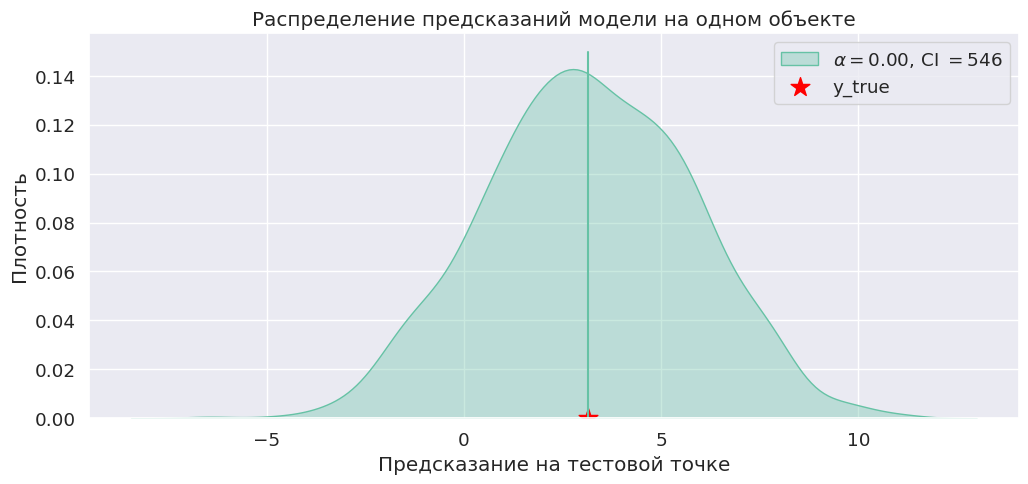

In [81]:
# Рассматриваем линейную регрессию
alpha = 0.0

y_preds, cond = single_prediction_variability(X, X_test_point, alpha)

# Записываем результаты эксперимента в общий словарь
predictions = {f"$\\alpha = {alpha:.2f}$, CI $= {cond:.0f}$": y_preds}
visualize_as_kde(
    predictions,
    y_test,
    (graph_title := "Распределение предсказаний модели на одном объекте"),
)

&#x2753; **Вопрос** &#x2753;

> Если данные изначально имеют единый масштаб, как здесь, нужна ли регуляризация? Какие причины могут повлиять на её необходимость?

<details>
  <summary> Кликни для показа ответа </summary>
  
> Единый масштаб признаков не связан с наличием либо отсутствием мультиколлинеарности. Регуляризация не нужна, только если есть уверенность в линейной **не**зависимости признаков или если регуляризованные модели дают худшее качество предсказания.

</details><br/>

Распределение ответов модели без регуляризации довольно широкое, т.е. модель неустойчива.

Сделаем $\alpha$ отличным от нуля.

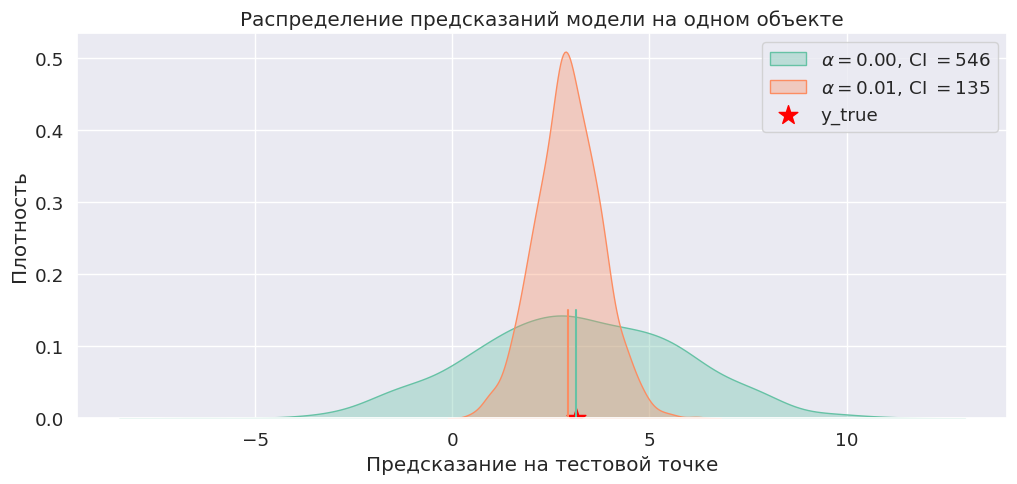

In [82]:
alpha = 0.01
y_preds, cond = single_prediction_variability(X, X_test_point, alpha)

# Записываем результаты эксперимента в общий словарь
predictions[f"$\\alpha = {alpha:.2f}$, CI $= {cond:.0f}$"] = y_preds

visualize_as_kde(predictions, y_test, graph_title)

**Вывод**

Разброс стал меньше, а число обусловленности уменьшилось. В этом и заключается стабилизирующий эффект регуляризации: предсказание модели меньше зависит от флуктуаций в данных.

Продолжаем увеличивать штраф:

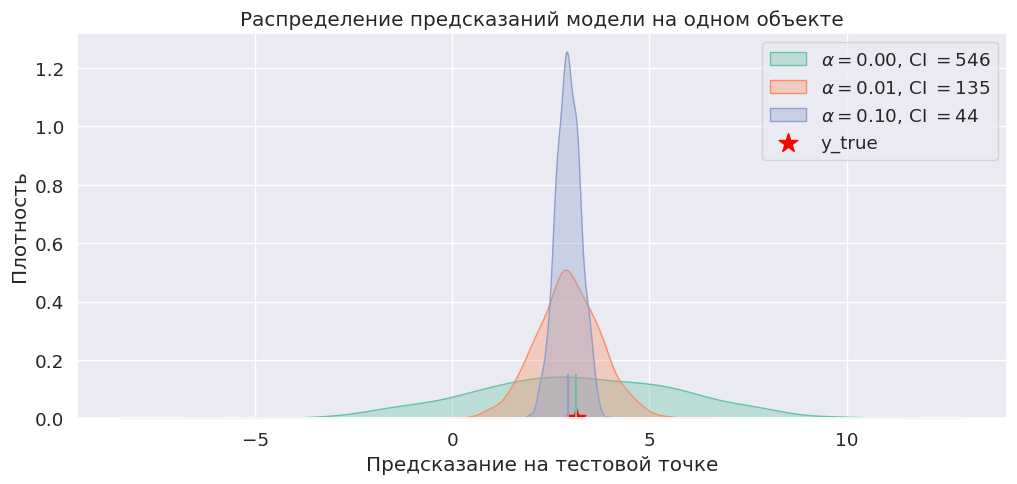

In [83]:
alpha = 0.1
y_preds, cond = single_prediction_variability(X, X_test_point, alpha)

# Записываем результаты эксперимента в общий словарь
predictions[f"$\\alpha = {alpha:.2f}$, CI $ = {cond:.0f}$"] = y_preds

visualize_as_kde(predictions, y_test, graph_title)

Дисперсия предказаний уменьшилась ещё сильнее. Плата за это улучшение &mdash; увеличенное смещение относительно истинного значения. Таким образом, оптимальный параметр регуляризации является компромиссом между уменьшением разброса предсказаний и смещением их матожидания.

&#x2753; **Вопрос** &#x2753;

> Почему число обусловленности уменьшается при регуляризации? Как это связано с тем, что мы добавили $\alpha I_5$ к матрице $X^TX$?

<details>
  <summary> Кликни для показа ответа </summary>
  
> Собственные числа матрицы $X^TX$ увеличились на константу, поэтому отношение наибольшего и наименьшего собственных чисел снизилось.

</details><br/>

&#x2753; **Вопрос** &#x2753;

> Можно ли применять регуляризацию, если число обусловленности мало?

<details>
  <summary> Кликни для показа ответа </summary>
  
> При маленьком числе обусловенности регуляризация скорее выльется в сильное смещение, нежели повысит устойчивость. Однако, не помешает посмотреть и на другие "маркеры" мультиколлинеарности, чтобы убедиться в её отсутствии. В конце концов, никто не запрещает взять и явно сравнить две модели: с регуляризацией и без.

</details><br/>

&#x2753; **Вопросы на закрепление** &#x2753;

> 1. Что такое мультиколлинеарность, и почему она приводит к нестабильности коэффициентов модели?

<details>
  <summary> Кликни для показа ответа </summary>
  
> Мультиколлинеарность &mdash; это наличие среди признаков зависимостей, близких к линейным. Случайный шум, присутствующий в этих зависимостях, приводит к нестабильности коэффициентов.

</details><br/>

> 2. Как регуляризация помогает бороться с мультиколлинеарностью?

<details>
  <summary> Кликни для показа ответа </summary>
  
> Регуляризация задаёт ограничение на норму коэффициентов модели, тем самым распределяя влияние между коррелированными признаками. $L_1$-регуляризация, помимо этого, зануляет часть коэффициентов.

</details><br/>